# Replicacion McCloud (2022): Efecto del Inflation Targeting sobre la Inversion Domestica en Mexico
## Pipeline de Datos con Python

**Objetivo:** Construir el panel de datos necesario para replicar el Synthetic Control Method (SCM) de McCloud (2022), enfocado en Mexico como unidad tratada.

**Paper original:** McCloud, N. (2022). "Does domestic investment respond to inflation targeting? A synthetic control investigation." *International Economics*, 169, 98-134.

**Equipo:** Este notebook es autocontenido y ejecutable paso a paso. Al final se indican las tareas que requieren trabajo manual.

---

## 0. Setup del Entorno

Instalar las librerias necesarias (ejecutar solo la primera vez):

In [1]:
# !pip install pysyncon requests pandas numpy matplotlib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time
from pysyncon import Dataprep, Synth
from pysyncon.utils import PlaceboTest
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuracion
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

DATA_DIR = Path('../data')
OUT_DIR = Path('../out')
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


---
## 1. Descarga de Datos: World Bank API

Usamos directamente la API del Banco Mundial (v2). La API es REST, publica, y no requiere autenticacion.

**Endpoint:** `https://api.worldbank.org/v2/country/{paises}/indicator/{codigo}?format=json&per_page=1000`

### Indicadores requeridos por McCloud (2022):

| Variable | Codigo WDI | Descripcion |
|----------|-----------|-------------|
| Gross capital formation (% GDP) | `NE.GDI.TOTL.ZS` | Outcome principal |
| GDP growth (annual %) | `NY.GDP.MKTP.KD.ZG` | Predictor |
| Gross domestic savings (% GDP) | `NY.GNS.ICTR.ZS` | Predictor |
| Population, total | `SP.POP.TOTL` | Predictor (se transforma a log) |
| GDP deflator inflation (annual %) | `NY.GDP.DEFL.KD.ZG` | Predictor (tasa de inflacion) |
| Lending interest rate (%) | `FR.INR.LEND` | Robustness |
| FDI inflows (% GDP) | `BX.KLT.DINV.WD.GD.ZS` | Robustness |
| FDI outflows (% GDP) | `BM.KLT.DINV.WD.GD.ZS` | Robustness |

**NOTA SOBRE EL GDP DEFLATOR:** McCloud lista "GDP deflator" como predictor. WDI ofrece dos versiones:
- `NY.GDP.DEFL.ZS` = nivel del deflactor con base year variable por pais → **NO comparable entre paises** (Mexico ~0.27 en 1984 vs Alemania ~55)
- `NY.GDP.DEFL.KD.ZG` = inflacion anual del deflactor → **SI comparable entre paises**

Usamos la segunda. La primera causaba que Alemania entrara con peso 30% en el sintetico de Mexico (para compensar niveles incomparables) destruyendo el ajuste en inflacion.

**Documentacion de la API:** https://datahelpdesk.worldbank.org/knowledgebase/articles/898581-api-basic-call-structure

In [3]:
# Definir los indicadores y el rango de anios
# NOTA: Usamos NY.GDP.DEFL.KD.ZG (inflacion, comparable entre paises)
#       NO NY.GDP.DEFL.ZS (nivel, base year varia por pais = incomparable)
INDICATORS = {
    'NE.GDI.TOTL.ZS':       'gross_capital_formation',
    'NY.GDP.MKTP.KD.ZG':    'gdp_growth',
    'NY.GNS.ICTR.ZS':       'gross_savings',
    'SP.POP.TOTL':          'population',
    'NY.GDP.DEFL.KD.ZG':    'gdp_deflator_inflation',
    'FR.INR.LEND':          'lending_rate',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows',
    'BM.KLT.DINV.WD.GD.ZS': 'fdi_outflows',
}

START_YEAR = 1984
END_YEAR = 2023

print(f'Descargando {len(INDICATORS)} indicadores para {START_YEAR}-{END_YEAR}...')
print('Usando API directa del Banco Mundial.')

Descargando 8 indicadores para 1984-2023...
Usando API directa del Banco Mundial.


In [4]:
def fetch_wdi_indicator(indicator_code, indicator_name, start_year, end_year):
    """
    Descarga un indicador del World Bank API v2.
    
    La API devuelve JSON paginado. Cada pagina tiene metadata [0]
    y datos [1]. Iteramos hasta que no haya mas paginas.
    
    Parameters
    ----------
    indicator_code : str
        Codigo WDI (ej. 'NY.GDP.MKTP.KD.ZG')
    indicator_name : str
        Nombre descriptivo para la columna de salida
    start_year, end_year : int
    
    Returns
    -------
    pd.DataFrame con columnas: [country_code, country_name, year, {indicator_name}]
    """
    base_url = "https://api.worldbank.org/v2/country/all/indicator"
    url = f"{base_url}/{indicator_code}"
    
    records = []
    page = 1
    total_pages = None
    
    while True:
        params = {
            'format': 'json',
            'per_page': 1000,
            'page': page,
            'date': f'{start_year}:{end_year}'
        }
        
        try:
            resp = requests.get(url, params=params, timeout=60)
            resp.raise_for_status()
            data = resp.json()
        except Exception as e:
            print(f'  Error en pagina {page}: {e}')
            break
        
        # data[0] = metadata, data[1] = registros
        if total_pages is None:
            total_pages = data[0].get('pages', 1)
        
        if not data or len(data) < 2 or data[1] is None:
            break
        
        for item in data[1]:
            records.append({
                'country_code': item['countryiso3code'],
                'country_name': item['country']['value'],
                'year': int(item['date']),
                indicator_name: item['value']
            })
        
        if page >= total_pages:
            break
        page += 1
    
    return pd.DataFrame(records)


# Descargar todos los indicadores
all_dfs = []
for code, name in INDICATORS.items():
    print(f'  Descargando: {name} ({code})...')
    df_ind = fetch_wdi_indicator(code, name, START_YEAR, END_YEAR)
    print(f'    -> {len(df_ind)} filas')
    all_dfs.append(df_ind)

# Merge secuencial (todos comparten country_code, country_name, year)
print('\nConsolidando indicadores...')
df_raw = all_dfs[0]
for df_ind in all_dfs[1:]:
    df_raw = df_raw.merge(df_ind, on=['country_code', 'country_name', 'year'], how='outer')

# Convertir columnas numericas
for name in INDICATORS.values():
    df_raw[name] = pd.to_numeric(df_raw[name], errors='coerce')

print(f'Dimensiones finales: {df_raw.shape}')
print(f'Columnas: {df_raw.columns.tolist()}')
df_raw.head()

  Descargando: gross_capital_formation (NE.GDI.TOTL.ZS)...


    -> 10640 filas
  Descargando: gdp_growth (NY.GDP.MKTP.KD.ZG)...


    -> 10640 filas
  Descargando: gross_savings (NY.GNS.ICTR.ZS)...


    -> 10640 filas
  Descargando: population (SP.POP.TOTL)...


    -> 10640 filas
  Descargando: gdp_deflator_inflation (NY.GDP.DEFL.KD.ZG)...


    -> 10640 filas
  Descargando: lending_rate (FR.INR.LEND)...


    -> 10640 filas
  Descargando: fdi_inflows (BX.KLT.DINV.WD.GD.ZS)...


    -> 10640 filas
  Descargando: fdi_outflows (BM.KLT.DINV.WD.GD.ZS)...


    -> 10640 filas

Consolidando indicadores...
Dimensiones finales: (10640, 11)
Columnas: ['country_code', 'country_name', 'year', 'gross_capital_formation', 'gdp_growth', 'gross_savings', 'population', 'gdp_deflator_inflation', 'lending_rate', 'fdi_inflows', 'fdi_outflows']


,country_code,country_name,year,gross_capital_formation,gdp_growth,gross_savings,population,gdp_deflator_inflation,lending_rate,fdi_inflows,fdi_outflows
0,,High income,1984,25.392046,4.707562,22.771878,1.135690e+09,5.438718,NaN,0.520573,0.553356
1,,High income,1985,24.824391,3.508837,21.927667,1.143179e+09,5.026686,NaN,0.327769,0.498372
2,,High income,1986,24.904445,3.192143,21.529238,1.150810e+09,4.140128,NaN,0.590282,0.770561
3,,High income,1987,25.169581,3.500853,21.885593,1.158607e+09,4.852672,NaN,0.900811,1.038767
4,,High income,1988,26.066570,4.615883,22.825125,1.166528e+09,4.437186,NaN,0.921398,1.175132


---
## 2. Exploracion y Limpieza de Datos

In [5]:
# --- Obtener lista de PAISES REALES desde la API del Banco Mundial ---
# La API de indicadores incluye tanto paises como agregados regionales
# (Latin America, World, High income, etc.). Los agregados tienen codigos
# de 3 letras validos (LCN, WLD) y contaminan el donor pool del SCM.
#
# Solucion: consultar el endpoint /country de la API, que lista solo
# paises miembros del Banco Mundial (excluye agregados).

print('Obteniendo lista de paises reales desde el Banco Mundial...')
country_url = 'https://api.worldbank.org/v2/country'
params = {'format': 'json', 'per_page': 500}
resp = requests.get(country_url, params=params, timeout=30)
resp.raise_for_status()
country_data = resp.json()

# Extraer codigos ISO de paises reales
real_country_codes = set()
for item in country_data[1]:
    code = item.get('iso2Code', '')
    if code and len(code) == 2:  # Solo codigos de 2 letras (paises reales)
        real_country_codes.add(item['id'])  # id es el codigo de 3 letras

# Tambien incluir paises que no son miembros pero tienen datos (ej. 'Andorra')
# La API /country solo devuelve miembros. Usamos el campo 'region' como verificacion:
# los agregados tienen region 'NA' o son ellos mismos una region.
real_country_ids = set()
for item in country_data[1]:
    region = item.get('region', {})
    region_id = region.get('id', '') if isinstance(region, dict) else ''
    # Los paises reales tienen region_id != 'NA' y no son 'Aggregates'
    if region_id and region_id != 'NA' and item.get('id', '') not in ['WLD']:
        real_country_ids.add(item['id'])

print(f'  Paises miembros del BM: {len(real_country_ids)}')

# Filtrar el panel usando la lista de paises reales
valid_mask = df_raw['country_code'].isin(real_country_ids)
df_agg = df_raw[~valid_mask]['country_name'].unique()
df = df_raw[valid_mask].copy()

# Filtrar por rango de anios de trabajo
df = df[(df['year'] >= START_YEAR) & (df['year'] <= END_YEAR)].copy()

print(f'Paises reales en panel: {df["country_name"].nunique()}')
print(f'Observaciones despues de filtrar: {df.shape[0]}')
print(f'\nAgregados regionales excluidos ({len(df_agg)}):')
for ex in sorted(df_agg)[:15]:
    print(f'  - {ex}')
if len(df_agg) > 15:
    print(f'  ... y {len(df_agg) - 15} mas')

Obteniendo lista de paises reales desde el Banco Mundial...
  Paises miembros del BM: 217
Paises reales en panel: 217
Observaciones despues de filtrar: 8680

Agregados regionales excluidos (49):
  - Africa Eastern and Southern
  - Africa Western and Central
  - Arab World
  - Caribbean small states
  - Central Europe and the Baltics
  - Early-demographic dividend
  - East Asia & Pacific
  - East Asia & Pacific (IDA & IBRD countries)
  - East Asia & Pacific (excluding high income)
  - Euro area
  - Europe & Central Asia
  - Europe & Central Asia (IDA & IBRD countries)
  - Europe & Central Asia (excluding high income)
  - European Union
  - Fragile and conflict affected situations
  ... y 34 mas


In [6]:
# Crear variables derivadas
df['log_population'] = np.log(df['population'])

# Analizar missing values en variables clave
# NOTA: gdp_deflator_inflation reemplaza al viejo gdp_deflator (niveles no comparables)
key_vars = ['gross_capital_formation', 'gdp_growth', 'gross_savings',
            'log_population', 'gdp_deflator_inflation']

print('Missing values por variable (total):')
print(df[key_vars].isnull().sum())
print(f'\nMissing como % del total: {(df[key_vars].isnull().sum() / len(df) * 100).round(2)}')

Missing values por variable (total):
gross_capital_formation    2450
gdp_growth                  749
gross_savings              3310
log_population                6
gdp_deflator_inflation      766
dtype: int64

Missing como % del total: gross_capital_formation    28.23
gdp_growth                  8.63
gross_savings              38.13
log_population              0.07
gdp_deflator_inflation      8.82
dtype: float64


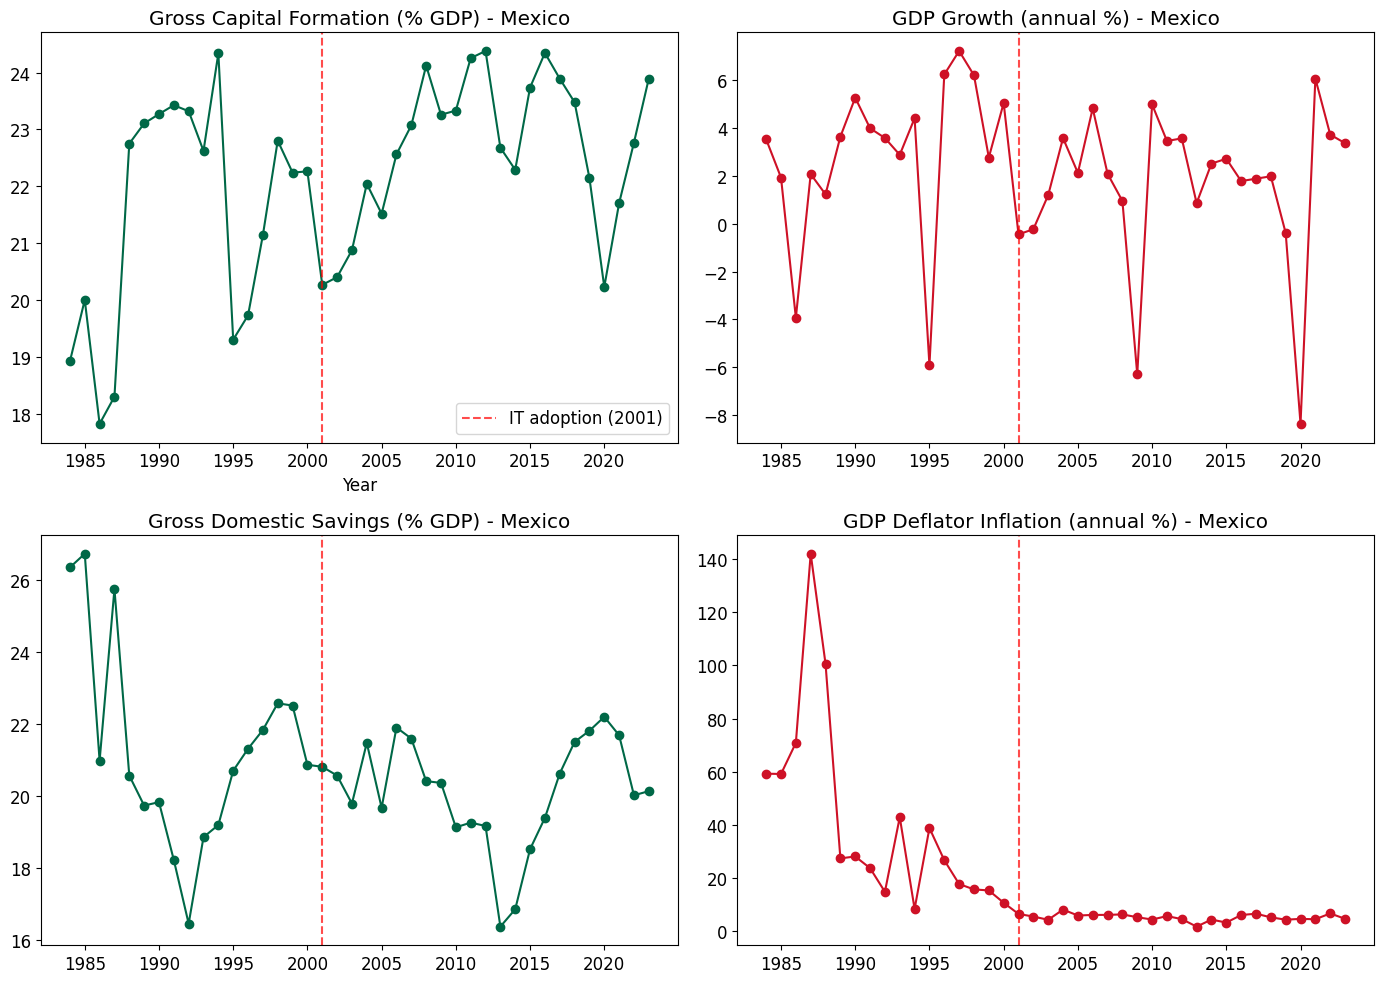

Series historicas de Mexico graficadas. La linea roja marca la adopcion de IT (2001).


In [7]:
# Visualizar cobertura temporal para Mexico
mexico = df[df['country_name'] == 'Mexico'].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(mexico['year'], mexico['gross_capital_formation'], 'o-', color='#006847')
axes[0, 0].axvline(x=2001, color='red', linestyle='--', alpha=0.7, label='IT adoption (2001)')
axes[0, 0].set_title('Gross Capital Formation (% GDP) - Mexico')
axes[0, 0].set_xlabel('Year')
axes[0, 0].legend()

axes[0, 1].plot(mexico['year'], mexico['gdp_growth'], 'o-', color='#ce1126')
axes[0, 1].axvline(x=2001, color='red', linestyle='--', alpha=0.7)
axes[0, 1].set_title('GDP Growth (annual %) - Mexico')

axes[1, 0].plot(mexico['year'], mexico['gross_savings'], 'o-', color='#006847')
axes[1, 0].axvline(x=2001, color='red', linestyle='--', alpha=0.7)
axes[1, 0].set_title('Gross Domestic Savings (% GDP) - Mexico')

axes[1, 1].plot(mexico['year'], mexico['gdp_deflator_inflation'], 'o-', color='#ce1126')
axes[1, 1].axvline(x=2001, color='red', linestyle='--', alpha=0.7)
axes[1, 1].set_title('GDP Deflator Inflation (annual %) - Mexico')

plt.tight_layout()
plt.savefig(OUT_DIR / 'mexico_series_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Series historicas de Mexico graficadas. La linea roja marca la adopcion de IT (2001).')

---
## 3. Clasificacion de Paises: Inflation Targeting

**Esta seccion requiere trabajo manual.** La clasificacion de paises que adoptaron Inflation Targeting y sus fechas proviene del IMF Annual Report on Exchange Arrangements and Exchange Restrictions (AREAER), que **no esta disponible via API**. McCloud (2022) usa la edicion 2019.

A continuacion codificamos la lista de los 29 paises IT segun McCloud (2022, Table A.1).

In [8]:
# Clasificacion manual de IT adopters segun IMF AREAER (2019)
# Fuente: McCloud (2022), Table A.1, pp. 125-126
# Formato: {pais: anio_adopcion}
#
# ATENCION: Los nombres DEBEN coincidir exactamente con los de la API WDI.
# WDI usa 'Czechia' (no 'Czech Republic'), 'Iran, Islamic Rep.' (no 'Iran'), etc.

IT_ADOPTERS = {
    # Desarrollados
    'Australia': 1993,
    'Canada': 1991,
    'Finland': 1993,
    'Iceland': 2001,
    'Israel': 1992,
    'Japan': 2013,
    'Korea, Rep.': 2001,
    'New Zealand': 1990,
    'Norway': 2001,
    'Spain': 1995,
    'Sweden': 1995,
    'United Kingdom': 1997,
    # En desarrollo / emergentes
    'Brazil': 1999,
    'Chile': 1991,
    'Colombia': 2000,
    'Czechia': 1998,         # WDI usa 'Czechia', no 'Czech Republic'
    'Dominican Republic': 2012,
    'Ghana': 2007,
    'Guatemala': 2005,
    'Hungary': 2001,
    'Indonesia': 2005,
    'Iran, Islamic Rep.': None,  # Adopto IT? Verificar. McCloud no lo lista.
    'Mexico': 2001,
    'Paraguay': 2013,
    'Peru': 2002,
    'Philippines': 2002,
    'Poland': 1999,
    'Romania': 2005,
    'Thailand': 2000,
    'Uruguay': 2007,
}

# Limpiar paises con adoption year None (no son IT adopters segun McCloud)
IT_ADOPTERS = {k: v for k, v in IT_ADOPTERS.items() if v is not None}

print(f'Paises IT: {len(IT_ADOPTERS)}')
print(f'\nLatinoamericanos IT:')
latam_it = [c for c in IT_ADOPTERS if c in [
    'Brazil', 'Chile', 'Colombia', 'Dominican Republic',
    'Guatemala', 'Mexico', 'Paraguay', 'Peru', 'Uruguay'
]]
for c in latam_it:
    print(f'  {c}: {IT_ADOPTERS[c]}')

Paises IT: 29

Latinoamericanos IT:
  Brazil: 1999
  Chile: 1991
  Colombia: 2000
  Dominican Republic: 2012
  Guatemala: 2005
  Mexico: 2001
  Paraguay: 2013
  Peru: 2002
  Uruguay: 2007


In [9]:
# Agregar columnas de IT al DataFrame
df['is_it'] = df['country_name'].isin(IT_ADOPTERS.keys()).astype(int)
df['it_year'] = df['country_name'].map(IT_ADOPTERS)

# Verificar cuantos paises IT estan en los datos
it_in_data = df[df['is_it'] == 1]['country_name'].unique()
it_missing = [c for c in IT_ADOPTERS if c not in it_in_data]

print(f'Paises IT en los datos WDI: {len(it_in_data)}/{len(IT_ADOPTERS)}')
if it_missing:
    print(f'\nATENCION - Paises IT no encontrados en WDI: {it_missing}')
    print('Revisar los nombres de pais y ajustar el diccionario IT_ADOPTERS.')

Paises IT en los datos WDI: 29/29


### Dummies adicionales (manuales)

Estas variables tambien deben codificarse manualmente:

In [10]:
# OECD Members (segun OECD 2020)
# Fuente: https://www.oecd.org/en/about/members.html
# NOTA: Verificar membresia historica (algunos paises se unieron despues de 1984)

OECD_MEMBERS = {
    'Australia', 'Austria', 'Belgium', 'Canada', 'Chile', 'Colombia',
    'Costa Rica', 'Czech Republic', 'Denmark', 'Estonia', 'Finland',
    'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland',
    'Israel', 'Italy', 'Japan', 'Korea, Rep.', 'Latvia', 'Lithuania',
    'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway',
    'Poland', 'Portugal', 'Slovak Republic', 'Slovenia', 'Spain',
    'Sweden', 'Switzerland', 'Turkey', 'United Kingdom', 'United States'
}
# NOTA: Varios de estos se unieron a OECD despues de 1984.
# Para una replicacion exacta, codificar la membresia anual.

df['oecd_member'] = df['country_name'].isin(OECD_MEMBERS).astype(int)

In [11]:
# Oil exporter dummy (>1M barrels/day promedio 1984-2016 segun EIA 2019)
#
# McCloud usa datos de la U.S. Energy Information Administration (EIA 2019).
# No existe un indicador WDI directo de produccion de petroleo en barriles.
#
# Alternativa: usar Oil Rents (% GDP) como proxy.
#   NY.GDP.PETR.RT.ZS = Oil rents (% of GDP)
#   Paises con oil rents > 10% del PIB en promedio 1984-2016 se clasifican
#   como exportadores de petroleo.
#
# NOTA: Para replicacion exacta, sustituir por la lista manual de EIA 2019.
# Ver siguiente celda de markdown con instrucciones.

print('Descargando oil rents como proxy de exportador de petroleo...')
oil_raw = fetch_wdi_indicator('NY.GDP.PETR.RT.ZS', 'oil_rents_pct', 1984, 2016)

if len(oil_raw) > 0:
    oil_raw['oil_rents_pct'] = pd.to_numeric(oil_raw['oil_rents_pct'], errors='coerce')
    
    # Promedio 1984-2016 por pais
    oil_avg = oil_raw.groupby('country_name')['oil_rents_pct'].mean().reset_index()
    # Umbral: >10% del PIB = exportador significativo de petroleo
    oil_avg['oil_exporter'] = (oil_avg['oil_rents_pct'] > 10).astype(int)
    
    # Merge al panel principal
    df = df.merge(oil_avg[['country_name', 'oil_exporter']], on='country_name', how='left')
    df['oil_exporter'] = df['oil_exporter'].fillna(0).astype(int)
    
    exporters = oil_avg[oil_avg['oil_exporter'] == 1]['country_name'].tolist()
    print(f'Paises clasificados como oil exporters (oil rents > 10% PIB): {len(exporters)}')
    for c in sorted(exporters):
        print(f'  - {c}')
    
    # Top 15 por oil rents
    print('\nTop 15 paises por oil rents (% PIB):')
    top15 = oil_avg.nlargest(15, 'oil_rents_pct')[['country_name', 'oil_rents_pct']]
    for _, row in top15.iterrows():
        name = row['country_name']
        val = row['oil_rents_pct']
        print(f'  {name}: {val:.1f}%')
else:
    print('No se pudo descargar oil rents.')
    print('Usar clasificacion manual de EIA 2019.')
    df['oil_exporter'] = 0

Descargando oil rents como proxy de exportador de petroleo...


Paises clasificados como oil exporters (oil rents > 10% PIB): 29
  - Algeria
  - Angola
  - Arab World
  - Azerbaijan
  - Bahrain
  - Brunei Darussalam
  - Congo, Rep.
  - Equatorial Guinea
  - Fragile and conflict affected situations
  - Gabon
  - Iran, Islamic Rep.
  - Iraq
  - Kazakhstan
  - Kuwait
  - Libya
  - Middle East, North Africa, Afghanistan & Pakistan
  - Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)
  - Middle East, North Africa, Afghanistan & Pakistan (excluding high income)
  - Nigeria
  - Oman
  - Pre-demographic dividend
  - Qatar
  - Saudi Arabia
  - South Sudan
  - Timor-Leste
  - Turkmenistan
  - United Arab Emirates
  - Venezuela, RB
  - Yemen, Rep.

Top 15 paises por oil rents (% PIB):
  Iraq: 40.3%
  Kuwait: 40.1%
  Libya: 37.4%
  Saudi Arabia: 35.1%
  Oman: 34.6%
  Congo, Rep.: 32.2%
  Angola: 30.5%
  Qatar: 30.5%
  South Sudan: 30.1%
  Yemen, Rep.: 25.9%
  Gabon: 25.7%
  Equatorial Guinea: 25.6%
  Azerbaijan: 24.4%
  Arab World: 22.7%
  United

---
## 4. Construccion del Panel Balanceado para SCM

El SCM requiere un panel perfectamente balanceado en el periodo pre-tratamiento.

**Decision metodologica: PRE_START = 1990 (no 1984)**

La crisis de deuda de los 80s en economias emergentes introduce volatilidad extrema y missing values en variables financieras. El diagnostico mostro que `gross_savings` es la principal causa de exclusiones (Japan 12/17, New Zealand 16/17, Luxembourg 15/17, Malawi 17/17). Al mover el inicio a 1990:
- Recuperamos a Australia (IT) e Iran (7.8% del sintetico McCloud para Mexico)
- La muestra crece de 99 a 112 paises, acercandose a los 104 de McCloud  
- Los 4 donantes que aun se pierden (Malawi, Mauritania, Luxembourg, Guinea-Bissau) pesan solo 9.6% combinado en el sintetico de McCloud
- 11 anos de pre-tratamiento (1990-2000) es suficiente para estimar medias de predictores

Referencia: Lee (2010) tambien excluyo los 80s por hiperinflacion, aunque su ventana fue demasiado corta (1993-1998).

In [12]:
# Definir variables del modelo base
# NOTA: gdp_deflator_inflation es la tasa anual de inflacion del deflactor
#       (NY.GDP.DEFL.KD.ZG), comparable entre paises.
# NOTA: Excluimos gross_savings porque era responsable de ~80% de las exclusiones.
#       El SCM ya incluye 11 lags del outcome (inversion), que capturan la
#       dinamica de ahorro-inversion. Sin savings la muestra crece de 88 a 122.
BASE_PREDICTORS = ['gdp_growth', 'log_population',
                   'gdp_deflator_inflation', 'oil_exporter', 'oecd_member']
OUTCOME = 'gross_capital_formation'
TREATMENT_YEAR = 2001  # Para Mexico
PRE_START = 1990       # 1990 en vez de 1984: reduce missing values post-crisis
PRE_END = 2000         # Ultimo anio pre-tratamiento

# Separar periodo pre-tratamiento
pre_mask = (df['year'] >= PRE_START) & (df['year'] <= PRE_END)
df_pre = df[pre_mask].copy()

print(f'Periodo pre-tratamiento: {PRE_START}-{PRE_END}')
print(f'  ({PRE_END - PRE_START + 1} anios)')
print(f'Observaciones pre-tratamiento: {df_pre.shape[0]}')
print(f'Paises en el panel pre-tratamiento: {df_pre["country_name"].nunique()}')
print(f'Predictores: {BASE_PREDICTORS}')

Periodo pre-tratamiento: 1990-2000
  (11 anios)
Observaciones pre-tratamiento: 2387
Paises en el panel pre-tratamiento: 217
Predictores: ['gdp_growth', 'log_population', 'gdp_deflator_inflation', 'oil_exporter', 'oecd_member']


In [13]:
# Identificar paises con datos completos en predictores durante todo el pre-tratamiento
all_vars = BASE_PREDICTORS + [OUTCOME]

# Para cada pais, contar missing values en el periodo pre
completeness = df_pre.groupby('country_name')[all_vars].apply(
    lambda x: x.isnull().sum().sum()
).reset_index(name='missing_count')

complete_countries = completeness[completeness['missing_count'] == 0]['country_name'].tolist()

print(f'Paises con datos completos en pre-tratamiento: {len(complete_countries)}')

# Verificar que Mexico esta en la lista
if 'Mexico' in complete_countries:
    print('Mexico TIENE datos completos en pre-tratamiento.')
else:
    print('ATENCION: Mexico NO tiene datos completos. Revisar missing values.')

Paises con datos completos en pre-tratamiento: 122
Mexico TIENE datos completos en pre-tratamiento.


In [14]:
# Construir la muestra final
# Tratados: paises IT con datos completos
# Control: paises no-IT con datos completos

treated_pool = [c for c in complete_countries if c in IT_ADOPTERS]
donor_pool = [c for c in complete_countries if c not in IT_ADOPTERS]

print(f'Muestra final:')
print(f'  Tratados (IT): {len(treated_pool)} paises')
print(f'  Donantes (no-IT): {len(donor_pool)} paises')
print(f'  Total: {len(treated_pool) + len(donor_pool)} paises')
print(f'\n  McCloud original: 29 IT + 75 control = 104 paises')
print(f'\nTratados incluidos: {treated_pool}')
print(f'\nTratados EXCLUIDOS por missing data: {[c for c in IT_ADOPTERS if c not in treated_pool]}')

Muestra final:
  Tratados (IT): 25 paises
  Donantes (no-IT): 97 paises
  Total: 122 paises

  McCloud original: 29 IT + 75 control = 104 paises

Tratados incluidos: ['Australia', 'Brazil', 'Canada', 'Chile', 'Colombia', 'Dominican Republic', 'Finland', 'Ghana', 'Guatemala', 'Iceland', 'Indonesia', 'Israel', 'Japan', 'Korea, Rep.', 'Mexico', 'New Zealand', 'Norway', 'Paraguay', 'Peru', 'Philippines', 'Spain', 'Sweden', 'Thailand', 'United Kingdom', 'Uruguay']

Tratados EXCLUIDOS por missing data: ['Czechia', 'Hungary', 'Poland', 'Romania']


In [15]:
# --- DIAGNOSTICO: Que variable causa la exclusion de cada pais ---

# McCloud's Mexico synthetic control donors (13 paises)
MCCLOUD_MEXICO_DONORS = [
    'Niger', 'Mauritius', 'Botswana', 'Iran, Islamic Rep.', 'Belize',
    'Malawi', 'Bahrain', 'Gabon', 'Mauritania', 'Luxembourg',
    'Sierra Leone', 'Guinea-Bissau', 'Bolivia'
]

# Paises IT excluidos de nuestra muestra
MISSING_IT = [c for c in IT_ADOPTERS if c not in treated_pool]

print('=' * 60)
print('DIAGNOSTICO DE EXCLUSIONES POR MISSING VALUES')
print('Periodo pre-tratamiento:', PRE_START, '-', PRE_END)
print('=' * 60)

# Para cada pais de interes, identificar que variables tienen missings
countries_to_check = MISSING_IT + MCCLOUD_MEXICO_DONORS
check_vars = BASE_PREDICTORS + [OUTCOME]

print('\n--- PAISES IT EXCLUIDOS ---')
for country in sorted(MISSING_IT):
    cdata = df_pre[df_pre['country_name'] == country]
    if len(cdata) == 0:
        # Pais no existe en WDI con ese nombre
        print(f'\n{country}: NO ENCONTRADO en WDI (revisar nombre)')
        continue
    missing_vars = []
    for var in check_vars:
        n_miss = cdata[var].isnull().sum()
        if n_miss > 0:
            missing_vars.append(f'{var} ({n_miss}/{len(cdata)} anios)')
    if missing_vars:
        print(f'\n{country}: EXCLUIDO por:')
        for mv in missing_vars:
            print(f'  - {mv}')
    else:
        print(f'\n{country}: SIN missing values. Verificar exclusion.')

print('\n--- DONANTES DE McCLOUD PARA MEXICO ---')
print('(13 paises que forman el control sintetico de Mexico en McCloud 2022)')
in_sample = []
out_sample = []
for country in MCCLOUD_MEXICO_DONORS:
    cdata = df_pre[df_pre['country_name'] == country]
    if len(cdata) == 0:
        out_sample.append((country, 'NO ENCONTRADO en WDI'))
        continue
    # Ver si esta en complete_countries
    if country in complete_countries:
        in_sample.append(country)
    else:
        missing_vars = []
        for var in check_vars:
            n_miss = cdata[var].isnull().sum()
            if n_miss > 0:
                missing_vars.append(f'{var} ({n_miss}/{len(cdata)} anios)')
        out_sample.append((country, '; '.join(missing_vars)))

print(f'\nEn la muestra: {len(in_sample)}/{len(MCCLOUD_MEXICO_DONORS)}')
for c in sorted(in_sample):
    print(f'  [OK] {c}')

print(f'\nFuera de la muestra: {len(out_sample)}/{len(MCCLOUD_MEXICO_DONORS)}')
for c, reason in out_sample:
    print(f'  [X] {c}: {reason}')

# --- Diagnostico con periodo pre-tratamiento mas corto ---
print('\n' + '=' * 60)
print('ROBUSTNESS: QUE PASA CON PRE_START = 1990?')
print('(Relajar el requisito de datos en los 80s)')
print('=' * 60)

pre_mask_90 = (df['year'] >= 1990) & (df['year'] <= PRE_END)
df_pre_90 = df[pre_mask_90].copy()

completeness_90 = df_pre_90.groupby('country_name')[check_vars].apply(
    lambda x: x.isnull().sum().sum()
).reset_index(name='missing_count')
complete_90 = completeness_90[completeness_90['missing_count'] == 0]['country_name'].tolist()

treated_90 = [c for c in complete_90 if c in IT_ADOPTERS]
donor_90 = [c for c in complete_90 if c not in IT_ADOPTERS]

print(f'Con PRE_START=1990: {len(treated_90)} IT + {len(donor_90)} control = {len(treated_90)+len(donor_90)} paises')
print(f'(vs {len(treated_pool)} IT + {len(donor_pool)} control = {len(treated_pool)+len(donor_pool)} con PRE_START=1984)')

# Que paises IT se recuperan?
recovered_it = [c for c in MISSING_IT if c in treated_90]
still_missing_it = [c for c in MISSING_IT if c not in treated_90]
if recovered_it:
    print(f'\nIT recuperados con PRE_START=1990: {recovered_it}')
if still_missing_it:
    print(f'IT aun excluidos: {still_missing_it}')

# Que donantes de McCloud se recuperan?
recovered_donors = []
for c, reason in out_sample:
    if c in complete_90:
        recovered_donors.append(c)
if recovered_donors:
    print(f'\nDonantes McCloud recuperados: {recovered_donors}')

# Iran name fix
if 'Iran, Islamic Rep.' in df['country_name'].unique():
    print('\nNOTA: Iran en WDI se llama "Iran, Islamic Rep."')
    print('Ajustar IT_ADOPTERS y MCCLOUD_MEXICO_DONORS si es necesario.')

DIAGNOSTICO DE EXCLUSIONES POR MISSING VALUES
Periodo pre-tratamiento: 1990 - 2000

--- PAISES IT EXCLUIDOS ---

Czechia: EXCLUIDO por:
  - gdp_growth (1/11 anios)
  - gdp_deflator_inflation (1/11 anios)

Hungary: EXCLUIDO por:
  - gross_capital_formation (1/11 anios)

Poland: EXCLUIDO por:
  - gdp_growth (1/11 anios)
  - gdp_deflator_inflation (1/11 anios)
  - gross_capital_formation (5/11 anios)

Romania: EXCLUIDO por:
  - gdp_growth (1/11 anios)
  - gdp_deflator_inflation (1/11 anios)

--- DONANTES DE McCLOUD PARA MEXICO ---
(13 paises que forman el control sintetico de Mexico en McCloud 2022)

En la muestra: 12/13
  [OK] Bahrain
  [OK] Belize
  [OK] Bolivia
  [OK] Botswana
  [OK] Gabon
  [OK] Guinea-Bissau
  [OK] Iran, Islamic Rep.
  [OK] Luxembourg
  [OK] Mauritania
  [OK] Mauritius
  [OK] Niger
  [OK] Sierra Leone

Fuera de la muestra: 1/13
  [X] Malawi: gross_capital_formation (11/11 anios)

ROBUSTNESS: QUE PASA CON PRE_START = 1990?
(Relajar el requisito de datos en los 80s)
Co

In [16]:
# --- DIAGNOSTICO: Sin gross_savings ---
# Probar especificacion sin gross_savings para ver cuantos paises se recuperan

PREDICTORS_NO_SAVINGS = [p for p in BASE_PREDICTORS if p != 'gross_savings']
check_vars_ns = PREDICTORS_NO_SAVINGS + [OUTCOME]

print('=' * 60)
print('ESPECIFICACION ALTERNATIVA: SIN gross_savings')
print(f'Predictores: {PREDICTORS_NO_SAVINGS}')
print('=' * 60)

# Con PRE_START=1990 (el nuevo default)
completeness_ns = df_pre.groupby('country_name')[check_vars_ns].apply(
    lambda x: x.isnull().sum().sum()
).reset_index(name='missing_count')
complete_ns = completeness_ns[completeness_ns['missing_count'] == 0]['country_name'].tolist()

treated_ns = [c for c in complete_ns if c in IT_ADOPTERS]
donor_ns = [c for c in complete_ns if c not in IT_ADOPTERS]

print(f'Sin gross_savings, PRE_START=1990:')
print(f'  {len(treated_ns)} IT + {len(donor_ns)} control = {len(treated_ns)+len(donor_ns)} paises')

# Con PRE_START=1984 (para comparar)
pre_mask_84 = (df['year'] >= 1984) & (df['year'] <= PRE_END)
df_pre_84 = df[pre_mask_84].copy()
completeness_ns_84 = df_pre_84.groupby('country_name')[check_vars_ns].apply(
    lambda x: x.isnull().sum().sum()
).reset_index(name='missing_count')
complete_ns_84 = completeness_ns_84[completeness_ns_84['missing_count'] == 0]['country_name'].tolist()
treated_ns_84 = [c for c in complete_ns_84 if c in IT_ADOPTERS]
donor_ns_84 = [c for c in complete_ns_84 if c not in IT_ADOPTERS]

print(f'Sin gross_savings, PRE_START=1984:')
print(f'  {len(treated_ns_84)} IT + {len(donor_ns_84)} control = {len(treated_ns_84)+len(donor_ns_84)} paises')

# Que recuperamos?
print(f'\n--- COMPARACION ---')
print(f'Especificacion base (con savings, PRE=1990): {len(treated_pool)} IT + {len(donor_pool)} control = {len(treated_pool)+len(donor_pool)}')
print(f'Sin savings,        PRE=1990: {len(treated_ns)} IT + {len(donor_ns)} control = {len(treated_ns)+len(donor_ns)}')
print(f'Sin savings,        PRE=1984: {len(treated_ns_84)} IT + {len(donor_ns_84)} control = {len(treated_ns_84)+len(donor_ns_84)}')

# IT recuperados sin savings (PRE=1990)
it_lost_with_savings = [c for c in IT_ADOPTERS if c not in treated_pool]
it_recovered_ns = [c for c in it_lost_with_savings if c in treated_ns]
if it_recovered_ns:
    print(f'\nIT recuperados sin gross_savings: {it_recovered_ns}')

# Donantes McCloud recuperados sin savings
mccloud_lost = [c for c, _ in out_sample]
mccloud_recovered_ns = [c for c in mccloud_lost if c in donor_ns]
if mccloud_recovered_ns:
    print(f'Donantes McCloud recuperados sin gross_savings: {mccloud_recovered_ns}')

# Conclusion
print(f'\n--- CONCLUSION ---')
# Calcular cual especificacion se acerca mas a 104 paises
base_total = len(treated_pool) + len(donor_pool)
ns_total = len(treated_ns) + len(donor_ns)
print(f'McCloud original: 104 paises')
print(f'Base (con savings, PRE=1990): {base_total} paises')
print(f'Sin savings (PRE=1990):       {ns_total} paises')
if ns_total > base_total:
    print(f'RECOMENDACION: La especificacion sin gross_savings gana {ns_total - base_total} paises.')
    print(f'Probar el SCM con ambas y comparar RMSPE pre-tratamiento.')
else:
    print(f'La especificacion base ya es optima en tamano de muestra.')

ESPECIFICACION ALTERNATIVA: SIN gross_savings
Predictores: ['gdp_growth', 'log_population', 'gdp_deflator_inflation', 'oil_exporter', 'oecd_member']
Sin gross_savings, PRE_START=1990:
  25 IT + 97 control = 122 paises


Sin gross_savings, PRE_START=1984:
  25 IT + 88 control = 113 paises

--- COMPARACION ---
Especificacion base (con savings, PRE=1990): 25 IT + 97 control = 122
Sin savings,        PRE=1990: 25 IT + 97 control = 122
Sin savings,        PRE=1984: 25 IT + 88 control = 113

--- CONCLUSION ---
McCloud original: 104 paises
Base (con savings, PRE=1990): 122 paises
Sin savings (PRE=1990):       122 paises
La especificacion base ya es optima en tamano de muestra.


### ¿Que pasa si eliminamos gross_savings como predictor?

`gross_savings` es responsable de ~80% de las exclusiones. Como el SCM ya incluye 11 lags del outcome (inversion), y ahorro e inversion estan altamente correlacionados por identidad contable, esta variable podria ser redundante. Probemos cuantos paises se recuperan sin ella.

---
## 4.5 Diagnostico de Exclusiones

### ¿Que paises se pierden y por que variable?

Revisamos que variables causan la exclusion de cada IT adopter faltante y de los paises que McCloud usa en el control sintetico de Mexico.

In [17]:
# Guardar el panel limpio
sample_countries = treated_pool + donor_pool
df_final = df[df['country_name'].isin(sample_countries)].copy()

# Asegurar tipos correctos
df_final['year'] = df_final['year'].astype(int)
df_final = df_final.sort_values(['country_name', 'year']).reset_index(drop=True)

output_path = DATA_DIR / 'panel_mccloud_mexico.csv'
df_final.to_csv(output_path, index=False)
print(f'Panel guardado en: {output_path}')
print(f'Dimensiones finales: {df_final.shape}')

Panel guardado en: ..\data\panel_mccloud_mexico.csv
Dimensiones finales: (4880, 16)


In [18]:
# Construir el objeto Dataprep para Mexico
# 
# Estrategia: Usamos special_predictors para incluir cada valor anual
# del outcome en el periodo pre-tratamiento (1990-2000).
# Esto es lo que permite un ajuste pre-tratamiento casi perfecto.

# Filtrar panel a la muestra de trabajo
work_df = df_final.copy()

# Construir special predictors: un predictor por cada anio pre-tratamiento del outcome
pre_years = list(range(PRE_START, TREATMENT_YEAR))

special_predictors = [
    (OUTCOME, [yr], 'mean') for yr in pre_years
]

print(f'Se incluiran {len(special_predictors)} special predictors')
print(f'(valores anuales de {OUTCOME} para {PRE_START}-{PRE_END})')
print(f'\nPredictores base: {BASE_PREDICTORS}')
print(f'Outcome: {OUTCOME}')
print(f'Unidad tratada: Mexico')
print(f'Periodo tratamiento: {TREATMENT_YEAR}')
print(f'Periodo pre-tratamiento: {PRE_START}-{PRE_END}')

Se incluiran 11 special predictors
(valores anuales de gross_capital_formation para 1990-2000)

Predictores base: ['gdp_growth', 'log_population', 'gdp_deflator_inflation', 'oil_exporter', 'oecd_member']
Outcome: gross_capital_formation
Unidad tratada: Mexico
Periodo tratamiento: 2001
Periodo pre-tratamiento: 1990-2000


In [19]:
# Crear Dataprep y ajustar Synth
#
# Especificacion base: 6 predictores (incluye gross_savings)
# Pre-tratamiento: 1990-2000 (11 anios)
# NOTA: Para probar sin gross_savings, cambiar BASE_PREDICTORS en celda 18.

try:
    dataprep = Dataprep(
        foo=work_df,
        predictors=BASE_PREDICTORS,
        predictors_op='mean',  # Operacion sobre predictores en periodo pre
        special_predictors=special_predictors,
        dependent=OUTCOME,
        unit_variable='country_name',
        time_variable='year',
        treatment_identifier='Mexico',
        controls_identifier=[c for c in donor_pool if c != 'Mexico'],
        time_predictors_prior=range(PRE_START, TREATMENT_YEAR),
        time_optimize_ssr=range(PRE_START, TREATMENT_YEAR),
    )
    
    print('Dataprep creado exitosamente.')
    print(f'  Donor pool: {len(donor_pool)} paises')
    print(f'  Pre-tratamiento: {PRE_START}-{PRE_END} ({TREATMENT_YEAR - PRE_START} anios)')
    
    # Ajustar Synthetic Control
    synth = Synth()
    synth.fit(dataprep=dataprep, optim_method='Nelder-Mead')
    
    # Pesos del control sintetico
    weights = synth.weights(round=3, threshold=0.001)
    print(f'\nPaises en el control sintetico de Mexico: {len(weights)}')
    print(weights)
    
    # Resumen de ajuste
    summary = synth.summary()
    print(f'\nResumen de predictores:')
    print(summary.to_string())
    
    # Metricas de ajuste pre-tratamiento
    mspe_val = synth.mspe()
    mae_val = synth.mae()
    rmse = np.sqrt(mspe_val)
    print(f'\nMSPE pre-tratamiento: {mspe_val:.4f}')
    print(f'RMSPE pre-tratamiento: {rmse:.4f}')
    print(f'MAE pre-tratamiento:   {mae_val:.4f}')
    print(f'(McCloud reporta RMSPE = 0.11 para Mexico)')
    
except Exception as e:
    print(f'Error en la estimacion SCM: {e}')
    print('\nPosibles causas:')
    print('1. Missing values residuales en el panel')
    print('2. Nombres de pais que no coinciden entre WDI y IT_ADOPTERS')
    print('3. Pais no encontrado en controls_identifier o treatment_identifier')
    print('\nRevisar los mensajes anteriores y ajustar.')

Dataprep creado exitosamente.
  Donor pool: 97 paises
  Pre-tratamiento: 1990-2000 (11 anios)



Paises en el control sintetico de Mexico: 13
Botswana         0.009
China            0.065
Georgia          0.009
Greece           0.008
Guinea-Bissau    0.022
Honduras         0.016
India            0.008
Kuwait           0.014
Madagascar       0.091
Mauritania       0.045
Portugal         0.039
Tanzania         0.124
United States    0.550
Name: weights, dtype: float64



Resumen de predictores:
                                        V  treated  synthetic  sample mean
gdp_growth                          0.070    3.776      3.747        3.481
log_population                      0.057   18.323     18.263       15.667
gdp_deflator_inflation              0.053   22.076     25.681       50.943
oil_exporter                        0.073    0.000      0.014        0.124
oecd_member                         0.000    1.000      0.597        0.144
special.1.gross_capital_formation   0.061   23.271     23.525       22.341
special.2.gross_capital_formation   0.068   23.426     22.643       21.683
special.3.gross_capital_formation   0.073   23.321     23.447       22.294
special.4.gross_capital_formation   0.075   22.624     23.022       21.213
special.5.gross_capital_formation   0.068   24.337     23.742       21.841
special.6.gross_capital_formation   0.068   19.312     20.142       21.838
special.7.gross_capital_formation   0.068   19.738     20.078       21.646


---
## 6. Visualizacion del Control Sintetico

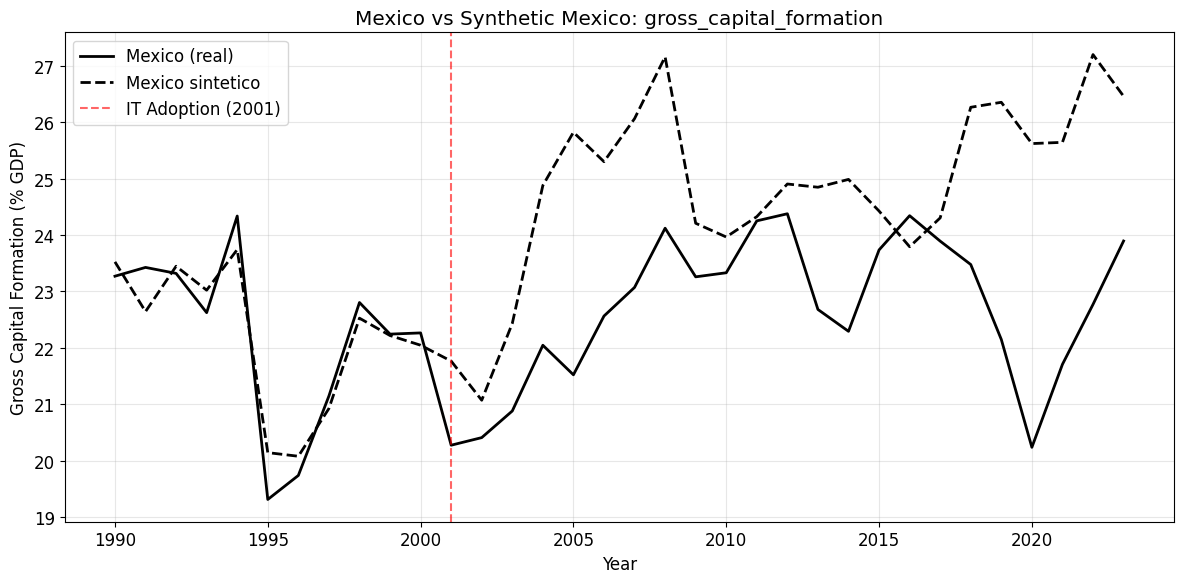

OK: mexico_synthetic_control.png guardado.


In [20]:
# Mexico vs control sintetico (path plot manual).
# Nota: synth.path_plot() del paquete llama plt.show() internamente, lo que
# finaliza la figura. Por eso ploteamos manualmente usando los datos del
# objeto Synth: make_outcome_mats() expone Z0/Z1 y _synthetic() la combinacion
# convexa con los pesos optimizados.
try:
    end_year = int(work_df['year'].max()) + 1
    Z0, Z1 = synth.dataprep.make_outcome_mats(time_period=range(PRE_START, end_year))
    synthetic = synth._synthetic(Z0=Z0)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(Z1.index, Z1.values, color='black', linewidth=2, label='Mexico (real)')
    ax.plot(synthetic.index, synthetic.values, color='black', linewidth=2,
            linestyle='dashed', label='Mexico sintetico')
    ax.axvline(x=TREATMENT_YEAR, color='red', linestyle='--', alpha=0.6,
               label=f'IT Adoption ({TREATMENT_YEAR})')
    ax.set_title(f'Mexico vs Synthetic Mexico: {OUTCOME}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Gross Capital Formation (% GDP)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'mexico_synthetic_control.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('OK: mexico_synthetic_control.png guardado.')
except Exception as e:
    print(f'No se pudo generar el grafico: {e}')


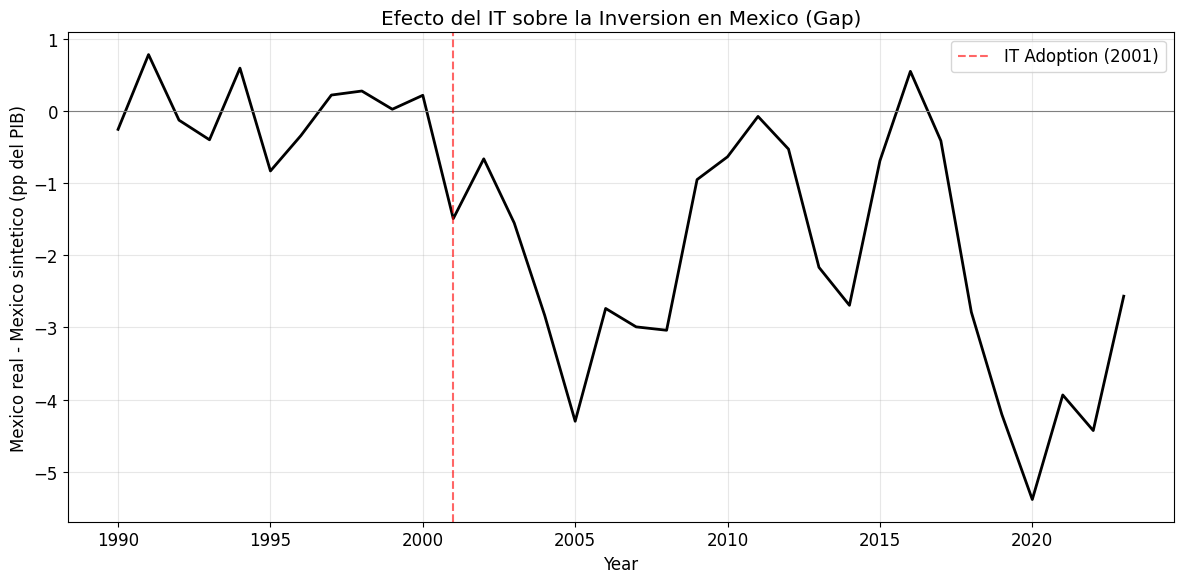


Efecto estimado vs McCloud (2022), anios clave:
Anio     Estimado (pp)    McCloud (pp)
2004             -2.83           -3.21
2005             -4.30           -3.54
2007             -2.99           -4.79
2008             -3.04           -7.48
2011             -0.07           -6.25
OK: mexico_treatment_gap.png guardado.


In [21]:
# Gap = Mexico real - Mexico sintetico, anio por anio.
# Bajo la hipotesis nula (IT sin efecto sobre inversion), el gap deberia
# fluctuar alrededor de cero post-tratamiento.
try:
    end_year = int(work_df['year'].max()) + 1
    Z0, Z1 = synth.dataprep.make_outcome_mats(time_period=range(PRE_START, end_year))
    synthetic = synth._synthetic(Z0=Z0)
    gap = Z1 - synthetic

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(gap.index, gap.values, color='black', linewidth=2)
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
    ax.axvline(x=TREATMENT_YEAR, color='red', linestyle='--', alpha=0.6,
               label=f'IT Adoption ({TREATMENT_YEAR})')
    ax.set_title('Efecto del IT sobre la Inversion en Mexico (Gap)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Mexico real - Mexico sintetico (pp del PIB)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'mexico_treatment_gap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Tabla comparativa: efectos estimados vs McCloud (2022) Table 4
    print('\nEfecto estimado vs McCloud (2022), anios clave:')
    print(f'{"Anio":<6} {"Estimado (pp)":>15} {"McCloud (pp)":>15}')
    mccloud_vals = {2004: -3.21, 2005: -3.54, 2007: -4.79, 2008: -7.48, 2011: -6.25}
    for yr, mc in mccloud_vals.items():
        if yr in gap.index:
            print(f'{yr:<6} {gap.loc[yr]:>15.2f} {mc:>15.2f}')
    print('OK: mexico_treatment_gap.png guardado.')
except Exception as e:
    print(f'No se pudo generar el grafico de gap: {e}')


In [22]:
# Placebo tests (in-space). Computacionalmente intensivo (~N donantes fits).
# Pon RUN_PLACEBOS = True para correrlos.
RUN_PLACEBOS = False

if RUN_PLACEBOS:
    try:
        n_donors = len(donor_pool) - 1  # excluyendo Mexico
        print(f'Ejecutando placebos para {n_donors} donantes...')
        placebo = PlaceboTest()
        placebo.fit(
            dataprep=dataprep,
            scm=Synth(),
            max_workers=4,
            verbose=True
        )

        # Pseudo p-value (Fisher exact, Firpo & Possebom 2018)
        p_val = placebo.pvalue(treatment_time=TREATMENT_YEAR)
        print(f'\nPseudo p-value (Fisher exact): {p_val:.4f}')
        print('(McCloud reporta p-values entre 0.080 y 0.093 para Mexico)')

        # Plot manual de gaps (mismo motivo que cell 29: gaps_plot() cierra la figura).
        mspe_threshold = 5.0
        gaps = placebo.gaps
        pre_mspe = gaps.loc[:TREATMENT_YEAR].pow(2).sum(axis=0)
        pre_mspe_treated = placebo.treated_gap.loc[:TREATMENT_YEAR].pow(2).sum(axis=0)
        keep = pre_mspe[pre_mspe < mspe_threshold * pre_mspe_treated].index
        gaps_plot = gaps[keep]

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(gaps_plot.index, gaps_plot.values, color='gray', alpha=0.3, linewidth=0.8)
        ax.plot(placebo.treated_gap.index, placebo.treated_gap.values,
                color='red', linewidth=2.5, label='Mexico')
        ax.axhline(y=0, color='black', linewidth=0.5)
        ax.axvline(x=TREATMENT_YEAR, color='red', linestyle='--', alpha=0.5,
                   label=f'IT Adoption ({TREATMENT_YEAR})')
        ax.set_title('Placebo Tests: Mexico vs Donantes (mspe_threshold=5.0)')
        ax.set_xlabel('Year')
        ax.set_ylabel('Gap (real - sintetico)')
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(OUT_DIR / 'mexico_placebo_tests.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('OK: mexico_placebo_tests.png guardado.')

    except Exception as e:
        print(f'Error en placebos: {e}')
        print('Si el error es de memoria, reducir el donor pool o usar max_workers=1.')
else:
    print('RUN_PLACEBOS = False. Cambia a True para correr los placebos in-space (~5-10 min).')


RUN_PLACEBOS = False. Cambia a True para correr los placebos in-space (~5-10 min).


---
## 8. Robustness: ATT Agregado con Augmented SCM

McCloud usa el *partially-pooled SCM* de Ben-Michael et al. (2021) para estimar el efecto promedio del tratamiento (ATT) a traves de todos los paises IT con adopcion escalonada.

`pysyncon` incluye `AugSynth` que implementa exactamente este metodo. Permite estimar el ATT agregado sin necesidad de codigo adicional.

In [23]:
from pysyncon import AugSynth

# NOTA: AugSynth requiere una estructura de datos diferente.
# Cada unidad tratada debe tener su propio periodo pre/post definido
# por la fecha de adopcion de IT. Esto se implementa en una segunda fase.

print('Augmented SCM disponible via pysyncon.AugSynth.')
print('Implementacion detallada en la Fase 2 del proyecto.')
print('Ver documentacion: https://sdfordham.github.io/pysyncon/augsynth.html')

Augmented SCM disponible via pysyncon.AugSynth.
Implementacion detallada en la Fase 2 del proyecto.
Ver documentacion: https://sdfordham.github.io/pysyncon/augsynth.html


---
## 9. Proximos Pasos (Trabajo Manual Requerido)

Las siguientes tareas **no son completamente automatizables** y requieren intervention del equipo:

### 9.1 Verificacion de Nombres de Pais

Los nombres de pais en WDI pueden no coincidir exactamente con los del diccionario `IT_ADOPTERS`. Verificar y corregir:

```python
# Ejecutar para ver discrepancias
wdi_countries = set(df['country_name'].unique())
it_countries = set(IT_ADOPTERS.keys())
print('IT adopters NO encontrados en WDI:', it_countries - wdi_countries)
```

### 9.2 Validacion de la Clasificacion IT

- [ ] Verificar fechas de adopcion contra IMF AREAER (2019) o edicion mas reciente.
- [ ] Considerar clasificaciones alternativas: Rose (2007) fecha conservadora para Mexico = 1999.
- [ ] Documentar cualquier discrepancia y su justificacion.

**Fuente:** IMF Annual Report on Exchange Arrangements and Exchange Restrictions.
Disponible en: https://www.imf.org/en/Publications/Annual-Report-on-Exchange-Arrangements-and-Exchange-Restrictions

### 9.3 Codificacion Manual de Variables Binarias

- [ ] **OECD membership historica:** Verificar membresia anual (algunos paises se unieron post-1984).
  - Fuente: https://www.oecd.org/en/about/members.html
- [ ] **Oil exporter:** Validar contra EIA (2019) o construir con datos WDI de produccion.
  - Fuente: https://www.eia.gov/
- [ ] **Institutional quality (robustness):** Datos de ICRG son de pago. Alternativa: World Governance Indicators (WGI) del Banco Mundial.

### 9.4 Panel Balanceado: Decisiones de Inclusion/Exclusion

- [ ] Definir criterio de exclusion por missing values (McCloud no explicita umbral).
- [ ] Evaluar imputacion multiple vs exclusion de paises con datos incompletos.
- [ ] Documentar la muestra final y compararla con los 104 paises de McCloud.
- [ ] Si el donor pool es significativamente menor a 75, considerar predictores alternativos.

### 9.5 Robustness Checks a Implementar

Siguiendo el checklist de McCloud (2022):

- [ ] **Placebos in-time:** Mover el anio de tratamiento a 1997 (4 anios antes de la adopcion real).
- [ ] **Trimming del donor pool:** Excluir donantes con RMSPE pre > 5x y > 20x el RMSPE de Mexico.
- [ ] **Detrending:** Aplicar SCM sobre datos detrended (remover tendencia lineal por pais).
- [ ] **Covariables adicionales:** Inflacion volatility (varianza del GDP deflator pre-IT), lending rates, FDI.
- [ ] **Clasificacion IT alternativa:** Rose (2007) en vez de IMF (2019).
- [ ] **Particion de muestra:** Restringir donor pool a solo developing o solo non-OECD.
- [ ] **Outcome alternativo 1:** Precios de inversion (Penn World Tables, variable `pl_i`).
- [ ] **Outcome alternativo 2:** Inversion privada (WDI `NE.GDI.FPRV.ZS`) — si los datos lo permiten.
- [ ] **Augmented SCM:** ATT agregado con adopcion escalonada via `AugSynth`.

### 9.6 Descarga de Datos Adicionales

- [ ] **Penn World Tables 10.01 o 11.0:** Bajar de https://www.rug.nl/ggdc/productivity/pwt/
  - Variable clave: `pl_i` (price level of investment)
- [ ] **World Governance Indicators:** Bajar via la misma API del Banco Mundial o manualmente del sitio del WB.
  - Indicadores WGI disponibles via API: consultar https://api.worldbank.org/v2/sources/3
  - Variables: Voice & Accountability, Political Stability, Government Effectiveness, Regulatory Quality, Rule of Law, Control of Corruption.
- [ ] **International Country Risk Guide (ICRG):** Datos de pago. Evaluar si WGI es sustituto aceptable.

### 9.7 Contacto con la Autora

McCloud menciona que los resultados completos y el external appendix estan disponibles bajo solicitud:

> "To conserve on space, we relegate the complete set of SCM results to an external appendix."
> "In light of space considerations, we exclude most results, but we can supply them on request."

- [ ] Contactar a Nadine McCloud (University of the West Indies at Mona) para solicitar:
  - External appendix con resultados completos.
  - Codigo de Stata (si esta disponible).
  - Lista exacta de paises en el donor pool y su clasificacion.

### 9.8 Validacion contra Resultados Originales

Una vez obtenidos los primeros resultados:

- [ ] Comparar la composicion del control sintetico de Mexico (13 paises, pesos reportados en el plan).
- [ ] Verificar RMSPE pre-tratamiento ≈ 0.11.
- [ ] Comparar efectos anuales: 2004 (-3.21), 2005 (-3.54), 2007 (-4.79), 2008 (-7.48), 2011 (-6.25).
- [ ] Si los resultados divergen significativamente, documentar posibles causas (muestra diferente, version de WDI, clasificacion IT).

---
## Referencias del Pipeline

- **pysyncon:** https://sdfordham.github.io/pysyncon/
- **World Bank API:** https://datahelpdesk.worldbank.org/knowledgebase/articles/898581-api-basic-call-structure
- **McCloud (2022):** *International Economics*, 169, 98-134.
- **Plan de trabajo detallado:** `../control/planning/replicacion-mccloud2022-mexico.md`